# Analisis Performa ConvNeXt-Tiny dalam Pengenalan Ekspresi Wajah pada Dataset FER+

Notebook ini dirapikan mengikuti alur CRISP-DM:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment


## 1. Business Understanding

Tujuan penelitian ini adalah menganalisis performa ConvNeXt-Tiny dalam mengenali ekspresi wajah pada dataset FER+ dan menilai apakah arsitektur tersebut cocok untuk konteks pengenalan ekspresi wajah yang memiliki label anotasi dari beberapa annotator.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%pip install -q timm split-folders

In [ ]:
import os, cv2, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import splitfolders

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset
from torchvision import transforms
import timm

from sklearn.metrics import classification_report, confusion_matrix
from torch.optim.lr_scheduler import CosineAnnealingLR

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


## 2. Data Understanding

Pada tahap ini, notebook meninjau masing-masing dataset terlebih dahulu untuk melihat jumlah baris, jumlah kolom, nama kolom, contoh data awal, dan struktur umum sebelum dilakukan pembersihan serta transformasi.

In [ ]:
fer_df     = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Emotion_detection/FER+/icml_face_data.csv')
ferplus_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Emotion_detection/FER+/fer2013new.csv')

fer_df.columns     = fer_df.columns.str.strip()
ferplus_df.columns = ferplus_df.columns.str.strip()

print('=== Data Understanding: FER raw dataset ===')
print(f'Shape         : {fer_df.shape}')
print(f'Jumlah kolom   : {fer_df.shape[1]}')
print(f'Nama kolom     : {list(fer_df.columns)}')
print('\nHead dataset FER:')
display(fer_df.head())
print('\nInfo dataset FER:')
fer_df.info()

print('\n=== Data Understanding: FER+ annotations dataset ===')
print(f'Shape         : {ferplus_df.shape}')
print(f'Jumlah kolom   : {ferplus_df.shape[1]}')
print(f'Nama kolom     : {list(ferplus_df.columns)}')
print('\nHead dataset FER+:')
display(ferplus_df.head())
print('\nInfo dataset FER+:')
ferplus_df.info()

# Rename kolom otomatis
fer_df = fer_df.rename(columns={
    [c for c in fer_df.columns if 'pixel'   in c.lower()][0]: 'pixels',
    [c for c in fer_df.columns if 'usage'   in c.lower()][0]: 'Usage',
    [c for c in fer_df.columns if 'emotion' in c.lower()][0]: 'emotion'
})
ferplus_df = ferplus_df.rename(columns={
    [c for c in ferplus_df.columns if 'usage' in c.lower()][0]: 'Usage'
})

EMOTION_COLS = ['neutral','happiness','surprise','sadness','anger','disgust','fear','contempt']

# Filter NF (no face): baris di mana NF > 0 dari semua voter
emotion_votes = ferplus_df[EMOTION_COLS].copy()
nf_votes      = ferplus_df['NF'] if 'NF' in ferplus_df.columns else pd.Series(0, index=ferplus_df.index)
total_votes   = emotion_votes.sum(axis=1)

fer_df['label']       = emotion_votes.idxmax(axis=1)
fer_df['total_votes'] = total_votes
fer_df['nf_votes']    = nf_votes.values

=== Data Understanding: FER raw dataset ===
Shape         : (35887, 3)
Jumlah kolom   : 3
Nama kolom     : ['emotion', 'Usage', 'pixels']

Head dataset FER:


,emotion,Usage,pixels
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...



Info dataset FER:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   emotion  35887 non-null  int64 
 1   Usage    35887 non-null  object
 2   pixels   35887 non-null  object
dtypes: int64(1), object(2)
memory usage: 841.2+ KB

=== Data Understanding: FER+ annotations dataset ===
Shape         : (35887, 12)
Jumlah kolom   : 12
Nama kolom     : ['Usage', 'Image name', 'neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt', 'unknown', 'NF']

Head dataset FER+:


,Usage,Image name,neutral,happiness,surprise,sadness,anger,disgust,fear,contempt,unknown,NF
0,Training,fer0000000.png,4,0,0,1,3,2,0,0,0,0
1,Training,fer0000001.png,6,0,1,1,0,0,0,0,2,0
2,Training,fer0000002.png,5,0,0,3,1,0,0,0,1,0
3,Training,fer0000003.png,4,0,0,4,1,0,0,0,1,0
4,Training,fer0000004.png,9,0,0,1,0,0,0,0,0,0



Info dataset FER+:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Usage       35887 non-null  object
 1   Image name  35714 non-null  object
 2   neutral     35887 non-null  int64 
 3   happiness   35887 non-null  int64 
 4   surprise    35887 non-null  int64 
 5   sadness     35887 non-null  int64 
 6   anger       35887 non-null  int64 
 7   disgust     35887 non-null  int64 
 8   fear        35887 non-null  int64 
 9   contempt    35887 non-null  int64 
 10  unknown     35887 non-null  int64 
 11  NF          35887 non-null  int64 
dtypes: int64(10), object(2)
memory usage: 3.3+ MB


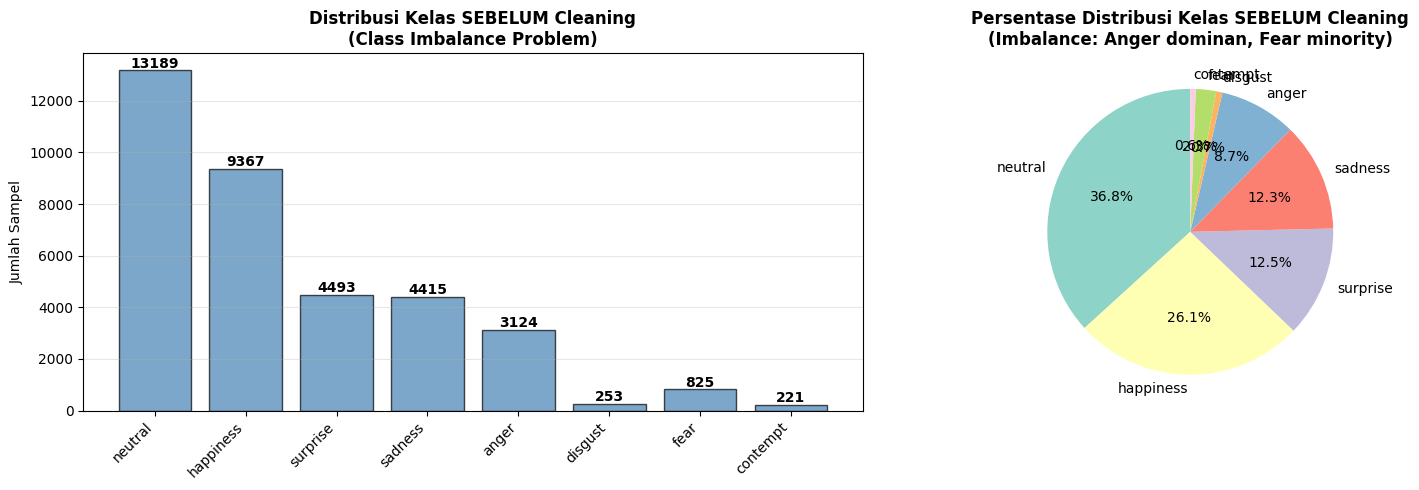

=== CLASS IMBALANCE STATISTICS (SEBELUM CLEANING) ===
Total samples: 35,887
Most frequent: neutral (13,189 samples)
Least frequent: contempt (221 samples)
Imbalance ratio: 59.68x

Distribusi per kelas:
label
neutral      13189
happiness     9367
surprise      4493
sadness       4415
anger         3124
fear           825
disgust        253
contempt       221
Name: count, dtype: int64

⚠️  Kesimpulan: Ada imbalance signifikan → gunakan WeightedRandomSampler di training


In [ ]:
EMOTION_COLS = ['neutral','happiness','surprise','sadness','anger','disgust','fear','contempt']

emotion_votes = ferplus_df[EMOTION_COLS].copy()
total_votes_per_row = emotion_votes.sum(axis=1)

# Asumsi: setiap gambar FER dipetakan ke FER+ berdasarkan index
# Label awal adalah kelas dengan votes tertinggi
fer_du = fer_df.copy()
fer_du['label'] = emotion_votes.idxmax(axis=1)
fer_du['total_votes'] = total_votes_per_row
fer_du['nf_votes'] = ferplus_df['NF'].values if 'NF' in ferplus_df.columns else 0

# Distribusi SEBELUM cleaning
label_dist_before = fer_du['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Raw distribution SEBELUM cleaning
label_dist_before_sorted = label_dist_before.reindex(EMOTION_COLS, fill_value=0)
axes[0].bar(range(len(label_dist_before_sorted)), label_dist_before_sorted.values, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xticks(range(len(EMOTION_COLS)))
axes[0].set_xticklabels(EMOTION_COLS, rotation=45, ha='right')
axes[0].set_title('Distribusi Kelas SEBELUM Cleaning\n(Class Imbalance Problem)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Jumlah Sampel')
axes[0].grid(axis='y', alpha=0.3)

# Tambahkan value label di atas bar
for i, v in enumerate(label_dist_before_sorted.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Hitung persentase
percentages = (label_dist_before_sorted / label_dist_before_sorted.sum() * 100).round(1)
axes[1].pie(label_dist_before_sorted.values, labels=EMOTION_COLS, autopct='%1.1f%%',
            colors=plt.cm.Set3(range(len(EMOTION_COLS))), startangle=90)
axes[1].set_title('Persentase Distribusi Kelas SEBELUM Cleaning\n(Imbalance: Anger dominan, Fear minority)', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('class_distribution_before_cleaning.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistik imbalance
print("=== CLASS IMBALANCE STATISTICS (SEBELUM CLEANING) ===")
print(f"Total samples: {label_dist_before.sum():,}")
print(f"Most frequent: {label_dist_before.idxmax()} ({label_dist_before.max():,} samples)")
print(f"Least frequent: {label_dist_before.idxmin()} ({label_dist_before.min():,} samples)")
print(f"Imbalance ratio: {label_dist_before.max() / label_dist_before.min():.2f}x")
print(f"\nDistribusi per kelas:\n{label_dist_before}")
print("\n⚠️  Kesimpulan: Ada imbalance signifikan → gunakan WeightedRandomSampler di training")


In [ ]:
print("NO FACE ANALYSIS")
print("="*60)

total_data = len(fer_du)
no_face = (fer_du['nf_votes'] > 0).sum()
clean_face = (fer_du['nf_votes'] == 0).sum()

print(f"Total data            : {total_data:,}")
print(f"Data dengan No Face   : {no_face:,}")
print(f"Data wajah valid      : {clean_face:,}")
print(f"Persentase No Face    : {no_face/total_data*100:.2f}%")

NO FACE ANALYSIS
Total data            : 35,887
Data dengan No Face   : 349
Data wajah valid      : 35,538
Persentase No Face    : 0.97%


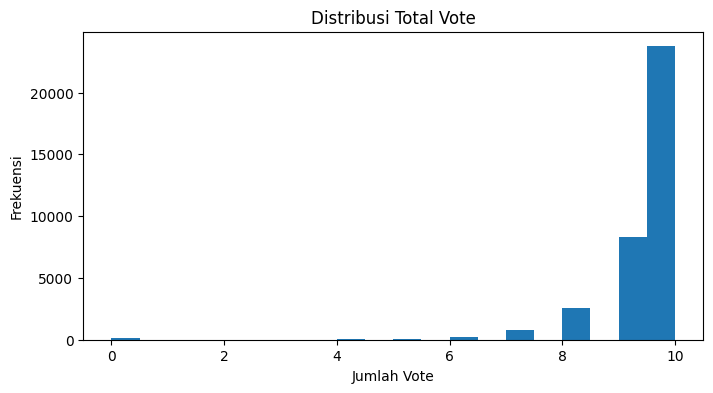

count    35887.000000
mean         9.473124
std          1.048267
min          0.000000
25%          9.000000
50%         10.000000
75%         10.000000
max         10.000000
Name: total_votes, dtype: float64


In [ ]:
plt.figure(figsize=(8,4))

fer_du['total_votes'].plot(kind='hist', bins=20)

plt.xlabel("Jumlah Vote")
plt.ylabel("Frekuensi")
plt.title("Distribusi Total Vote")
plt.show()

print(fer_du['total_votes'].describe())

count    35711.000000
mean         0.770331
std          0.198190
min          0.200000
25%          0.600000
50%          0.800000
75%          1.000000
max          1.000000
dtype: float64


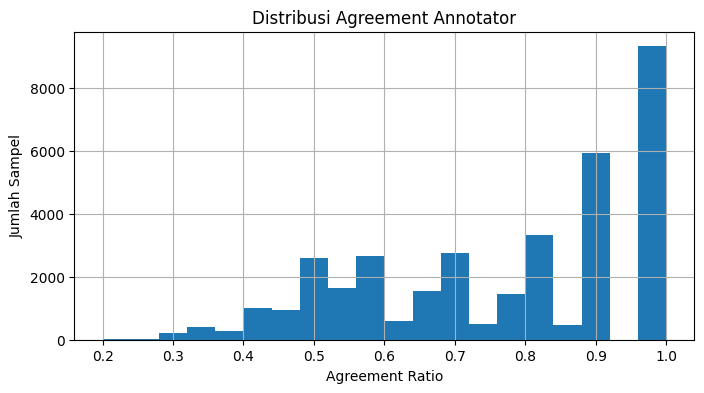

In [ ]:
dominant_vote = emotion_votes.max(axis=1)
agreement = dominant_vote / fer_du['total_votes']
print(agreement.describe())

plt.figure(figsize=(8,4))
agreement.hist(bins=20)
plt.xlabel("Agreement Ratio")
plt.ylabel("Jumlah Sampel")
plt.title("Distribusi Agreement Annotator")
plt.show()

In [ ]:
pixel_length = fer_du['pixels'].str.split().apply(len)
print(pixel_length.describe())
print(pixel_length.value_counts())

print("Ukuran unik pixel:")
print(pixel_length.unique())

count    35887.0
mean      2304.0
std          0.0
min       2304.0
25%       2304.0
50%       2304.0
75%       2304.0
max       2304.0
Name: pixels, dtype: float64
pixels
2304    35887
Name: count, dtype: int64
Ukuran unik pixel:
[2304]


In [ ]:
missing = fer_du.isnull().sum()
display(missing)

,0
emotion,0
Usage,0
pixels,0
label,0
total_votes,0
nf_votes,0


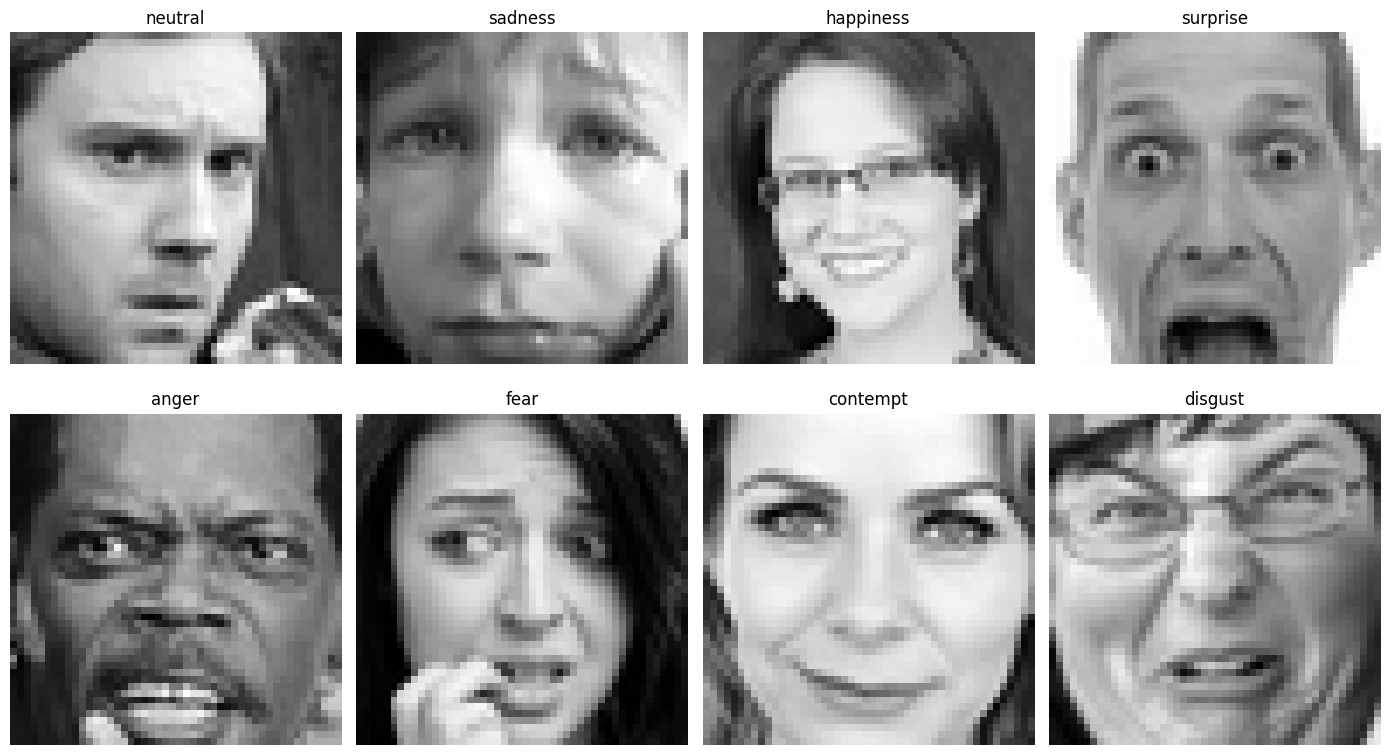

In [ ]:
labels = fer_du['label'].unique()

plt.figure(figsize=(14,8))

for i,label in enumerate(labels):

    idx = fer_du[fer_du['label']==label].index[0]

    img = np.array(
        fer_du.loc[idx,'pixels'].split(),
        dtype=np.uint8
    ).reshape(48,48)

    plt.subplot(2,4,i+1)
    plt.imshow(img,cmap='gray')
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
fer_du.head()

,emotion,Usage,pixels,label,total_votes,nf_votes
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,neutral,10,0
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...,neutral,8,0
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...,neutral,9,0
3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,neutral,9,0
4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,neutral,10,0


## 3. Data Preparation

Setelah struktur data dipahami, data dibersihkan, label diselaraskan, dan citra diekspor ke folder per kelas agar siap dipakai pada proses pelatihan model.

In [ ]:
print(fer_df.columns.tolist())

['emotion', 'Usage', 'pixels', 'label', 'total_votes', 'nf_votes']


In [ ]:
# Buang NF dan baris invalid
fer_clean = fer_df[
    (fer_df['total_votes'] > 0) &
    (fer_df['label'].isin(EMOTION_COLS)) &
    (fer_df['nf_votes'] < fer_df['total_votes'])  # bukan pure NF
].copy()

# Soft label distribution digunakan untuk KLDivLoss
soft_label_dict = {}
for orig_idx in fer_clean.index:
    votes = emotion_votes.loc[orig_idx] if orig_idx in emotion_votes.index else None
    if votes is None:
        continue
    total = total_votes.loc[orig_idx]
    soft_label_dict[int(orig_idx)] = (votes / total).values.astype(np.float32)

print(f"Total data valid : {len(fer_clean)}")
print(fer_clean['label'].value_counts())
print(f"Soft label dict  : {len(soft_label_dict)} sampel")

Total data valid : 35709
label
neutral      13013
happiness     9367
surprise      4493
sadness       4414
anger         3123
fear           825
disgust        253
contempt       221
Name: count, dtype: int64
Soft label dict  : 35709 sampel


In [ ]:
print("Data awal :", len(fer_df))
print("Data setelah filtering :", len(fer_clean))
print("Data terhapus :", len(fer_df) - len(fer_clean))

Data awal : 35887
Data setelah filtering : 35709
Data terhapus : 178


In [ ]:
fer_clean.head()

,emotion,Usage,pixels,label,total_votes,nf_votes
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,neutral,10,0
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...,neutral,8,0
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...,neutral,9,0
3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,neutral,9,0
4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,neutral,10,0


In [ ]:
OUTPUT_BASE = '/content/ferplus_images'

for emotion in EMOTION_COLS:
    os.makedirs(os.path.join(OUTPUT_BASE, emotion), exist_ok=True)

print(f"Mengekspor {len(fer_clean)} gambar...")
for i, (idx, row) in enumerate(fer_clean.iterrows()):
    try:
        pixels   = np.array(row['pixels'].strip().split(), dtype=np.uint8).reshape(48, 48)
        img_rgb  = cv2.cvtColor(pixels, cv2.COLOR_GRAY2RGB)
        cv2.imwrite(os.path.join(OUTPUT_BASE, row['label'], f"img_{idx:07d}.png"), img_rgb)
    except: pass
    if (i+1) % 5000 == 0: print(f"  {i+1}/{len(fer_clean)} done")

print("Ekspor selesai.")

Mengekspor 35709 gambar...
  5000/35709 done
  10000/35709 done
  15000/35709 done
  20000/35709 done
  25000/35709 done
  30000/35709 done
  35000/35709 done
Ekspor selesai.


In [ ]:
SPLIT_OUTPUT = '/content/ferplus_split'
splitfolders.ratio(OUTPUT_BASE, output=SPLIT_OUTPUT, seed=42, ratio=(.8, .1, .1))

for split in ['train','val','test']:
    p = os.path.join(SPLIT_OUTPUT, split)
    total = sum(len(os.listdir(os.path.join(p,e))) for e in os.listdir(p) if os.path.isdir(os.path.join(p,e)))
    print(f"{split}: {total}")

Copying files: 35709 files [00:05, 7123.51 files/s]


train: 28564
val: 3568
test: 3577


In [ ]:
class FERDataset(Dataset):
    def __init__(self, folder, transform=None, class_names=None, soft_label_map=None):
        self.transform = transform
        self.classes = list(class_names) if class_names is not None else sorted(os.listdir(folder))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        self.soft_label_map = soft_label_map or {}
        self.samples = []
        for cls in self.classes:
            cls_dir = os.path.join(folder, cls)
            if not os.path.isdir(cls_dir):
                continue
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith('.png'):
                    self.samples.append((os.path.join(cls_dir, fname), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        from PIL import Image
        img = Image.fromarray(img)
        if self.transform:
            img = self.transform(img)

        file_stem = os.path.splitext(os.path.basename(path))[0]
        try:
            orig_idx = int(file_stem.split('_')[-1])
        except ValueError:
            orig_idx = None

        soft_target = self.soft_label_map.get(orig_idx)
        if soft_target is None:
            soft_target = np.zeros(len(self.classes), dtype=np.float32)
            soft_target[label] = 1.0

        soft_target = torch.tensor(soft_target, dtype=torch.float32)
        hard_target = torch.tensor(label, dtype=torch.long)
        return img, soft_target, hard_target

# Transform training (augmentasi)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomAffine(degrees=10),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

# Transform val/test (tanpa augmentasi)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

train_dataset = FERDataset(os.path.join(SPLIT_OUTPUT, 'train'), train_transform, class_names=EMOTION_COLS, soft_label_map=soft_label_dict)
val_dataset   = FERDataset(os.path.join(SPLIT_OUTPUT, 'val'),   val_transform,   class_names=EMOTION_COLS, soft_label_map=soft_label_dict)
test_dataset  = FERDataset(os.path.join(SPLIT_OUTPUT, 'test'),  val_transform,   class_names=EMOTION_COLS, soft_label_map=soft_label_dict)

NUM_CLASSES = len(train_dataset.classes)
CLASS_NAMES = train_dataset.classes
print(f"Kelas: {CLASS_NAMES}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Kelas: ['neutral', 'happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear', 'contempt']
Train: 28564 | Val: 3568 | Test: 3577


In [ ]:
labels_train = [s[1] for s in train_dataset.samples]
class_counts = np.bincount(labels_train)
class_weights = 1.0 / class_counts                      # bobot per kelas
sample_weights = [class_weights[l] for l in labels_train]  # bobot per sampel

sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True
)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=2)

print(f"Train batches: {len(train_loader)}")

Train batches: 893


In [ ]:
classes = train_dataset.classes

for i, count in enumerate(class_counts):
    print(f"Kelas {i} ({classes[i]}): {count} sampel")

Kelas 0 (neutral): 10410 sampel
Kelas 1 (happiness): 7493 sampel
Kelas 2 (surprise): 3594 sampel
Kelas 3 (sadness): 3531 sampel
Kelas 4 (anger): 2498 sampel
Kelas 5 (disgust): 202 sampel
Kelas 6 (fear): 660 sampel
Kelas 7 (contempt): 176 sampel


In [ ]:
for i, w in enumerate(class_weights):
    print(f"Kelas {i} ({classes[i]}): weight = {w:.4f}")

Kelas 0 (neutral): weight = 0.0001
Kelas 1 (happiness): weight = 0.0001
Kelas 2 (surprise): weight = 0.0003
Kelas 3 (sadness): weight = 0.0003
Kelas 4 (anger): weight = 0.0004
Kelas 5 (disgust): weight = 0.0050
Kelas 6 (fear): weight = 0.0015
Kelas 7 (contempt): weight = 0.0057


In [ ]:
for i in range(10):  # lihat 10 pertama aja
    label = labels_train[i]
    print(f"Sample {i}: class = {classes[label]}, weight = {sample_weights[i]:.4f}")

Sample 0: class = neutral, weight = 0.0001
Sample 1: class = neutral, weight = 0.0001
Sample 2: class = neutral, weight = 0.0001
Sample 3: class = neutral, weight = 0.0001
Sample 4: class = neutral, weight = 0.0001
Sample 5: class = neutral, weight = 0.0001
Sample 6: class = neutral, weight = 0.0001
Sample 7: class = neutral, weight = 0.0001
Sample 8: class = neutral, weight = 0.0001
Sample 9: class = neutral, weight = 0.0001


In [ ]:
from collections import defaultdict

class_sample_weights = defaultdict(list)

for label, weight in zip(labels_train, sample_weights):
    class_sample_weights[label].append(weight)

for label in class_sample_weights:
    weights = class_sample_weights[label]
    print(f"Kelas {label} ({classes[label]}):")
    print(f"  jumlah sampel : {len(weights)}")
    print(f"  weight unik   : {set([round(w,4) for w in weights])}")

Kelas 0 (neutral):
  jumlah sampel : 10410
  weight unik   : {np.float64(0.0001)}
Kelas 1 (happiness):
  jumlah sampel : 7493
  weight unik   : {np.float64(0.0001)}
Kelas 2 (surprise):
  jumlah sampel : 3594
  weight unik   : {np.float64(0.0003)}
Kelas 3 (sadness):
  jumlah sampel : 3531
  weight unik   : {np.float64(0.0003)}
Kelas 4 (anger):
  jumlah sampel : 2498
  weight unik   : {np.float64(0.0004)}
Kelas 5 (disgust):
  jumlah sampel : 202
  weight unik   : {np.float64(0.005)}
Kelas 6 (fear):
  jumlah sampel : 660
  weight unik   : {np.float64(0.0015)}
Kelas 7 (contempt):
  jumlah sampel : 176
  weight unik   : {np.float64(0.0057)}


In [ ]:
from collections import Counter

sampled_labels = []

for idx in sampler:
    sampled_labels.append(labels_train[idx])

counter = Counter(sampled_labels)

for label, count in counter.items():
    print(f"Kelas {label} ({classes[label]}): {count}")

Kelas 3 (sadness): 3636
Kelas 5 (disgust): 3637
Kelas 6 (fear): 3519
Kelas 1 (happiness): 3475
Kelas 0 (neutral): 3569
Kelas 7 (contempt): 3555
Kelas 4 (anger): 3606
Kelas 2 (surprise): 3567


## 4. Modeling

Tahap ini membangun ConvNeXt-Tiny sebagai model klasifikasi ekspresi wajah dan menyiapkannya untuk proses training.

In [ ]:
model = timm.create_model('convnext_tiny', pretrained=True, num_classes=NUM_CLASSES, drop_rate=0.3, drop_path_rate=0.2)
model = model.to(DEVICE)

USE_GRAPH_MODE = True
if USE_GRAPH_MODE and hasattr(torch, 'compile'):
    try:
        model = torch.compile(model)
        print('Graph mode aktif via torch.compile')
    except Exception as exc:
        print(f'Graph mode tidak aktif, fallback ke eager mode: {exc}')
else:
    print('Graph mode tidak tersedia; tetap memakai eager mode')

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Graph mode aktif via torch.compile
Total params     : 27,826,280
Trainable params : 27,826,280


In [ ]:
# ============================================================
# Loss Function: KLDivLoss dengan soft label FER+
# Optimizer: Adam lr=1e-4
# Scheduler: CosineAnnealingLR (smooth learning rate decay)
# ============================================================
#
# CATATAN TEKNIS:
# Skenario ini memakai distribusi vote 10 annotator FER+ sebagai
# soft target, sehingga model belajar uncertainty antar kelas.
# ============================================================

# Loss Function: KLDivLoss
criterion = nn.KLDivLoss(reduction='batchmean')

# Optimizer: Adam dengan learning rate conservative
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Scheduler: CosineAnnealingLR untuk smooth decay
scheduler = CosineAnnealingLR(optimizer, T_max=30, eta_min=1e-6)

print('Loss Function: KLDivLoss + soft targets')
print('Soft labels: distribusi vote FER+ per sampel')
print(f"Optimizer: Adam (lr=1e-4)")
print(f"Scheduler: CosineAnnealingLR (T_max=30, eta_min=1e-6)")

Loss Function: KLDivLoss + soft targets
Soft labels: distribusi vote FER+ per sampel
Optimizer: Adam (lr=1e-4)
Scheduler: CosineAnnealingLR (T_max=30, eta_min=1e-6)


In [ ]:
MODEL_MODE = 'graph' if USE_GRAPH_MODE and hasattr(torch, 'compile') else 'eager'
print(f'Training mode: {MODEL_MODE}')

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, soft_targets, labels in loader:
        imgs = imgs.to(DEVICE)
        soft_targets = soft_targets.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        log_probs = F.log_softmax(outputs, dim=1)
        loss = criterion(log_probs, soft_targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, soft_targets, labels in loader:
            imgs = imgs.to(DEVICE)
            soft_targets = soft_targets.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(imgs)
            log_probs = F.log_softmax(outputs, dim=1)
            loss = criterion(log_probs, soft_targets)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), correct / total

EPOCHS = 100
best_val_acc = 0
history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

print(f"Training ConvNeXt-Tiny | {EPOCHS} epochs | device={DEVICE} | mode={MODEL_MODE}")
print("="*60)

patience = 7
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        best_val_acc = vl_acc
        patience_counter = 0
        torch.save(model.state_dict(), 'best_convnext_ferplus.pth')
        flag = '← saved'
    else:
        patience_counter += 1
        flag = f'patience {patience_counter}/{patience}'
        if patience_counter >= patience:
            print(f"Early stopping di epoch {epoch}")
            break

    print(f"Ep {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {tr_loss:.4f} Acc: {tr_acc*100:.2f}% | "
          f"Val Loss: {vl_loss:.4f} Acc: {vl_acc*100:.2f}% {flag}")

print(f"\nBest Val Loss: {best_val_loss:.4f}")
print(f"Best Val Accuracy: {best_val_acc*100:.2f}%")

Training mode: graph
Training ConvNeXt-Tiny | 100 epochs | device=cuda | mode=graph


/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:322: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


Ep 01/100 | Train Loss: 0.7392 Acc: 52.15% | Val Loss: 0.4585 Acc: 72.81% ← saved
Ep 02/100 | Train Loss: 0.3400 Acc: 78.13% | Val Loss: 0.3895 Acc: 77.77% ← saved
Ep 03/100 | Train Loss: 0.2764 Acc: 82.02% | Val Loss: 0.3431 Acc: 80.58% ← saved
Ep 04/100 | Train Loss: 0.2385 Acc: 83.56% | Val Loss: 0.3180 Acc: 82.93% ← saved
Ep 05/100 | Train Loss: 0.2135 Acc: 85.14% | Val Loss: 0.2956 Acc: 83.02% ← saved
Ep 06/100 | Train Loss: 0.1966 Acc: 86.31% | Val Loss: 0.3064 Acc: 82.85% patience 1/7
Ep 07/100 | Train Loss: 0.1824 Acc: 87.17% | Val Loss: 0.2950 Acc: 83.27% ← saved
Ep 08/100 | Train Loss: 0.1661 Acc: 88.16% | Val Loss: 0.2828 Acc: 83.94% ← saved
Ep 09/100 | Train Loss: 0.1568 Acc: 88.60% | Val Loss: 0.2961 Acc: 82.46% patience 1/7
Ep 10/100 | Train Loss: 0.1436 Acc: 89.09% | Val Loss: 0.2838 Acc: 85.03% patience 2/7
Ep 11/100 | Train Loss: 0.1362 Acc: 89.55% | Val Loss: 0.2783 Acc: 84.98% ← saved
Ep 12/100 | Train Loss: 0.1267 Acc: 90.00% | Val Loss: 0.2875 Acc: 84.25% patience 

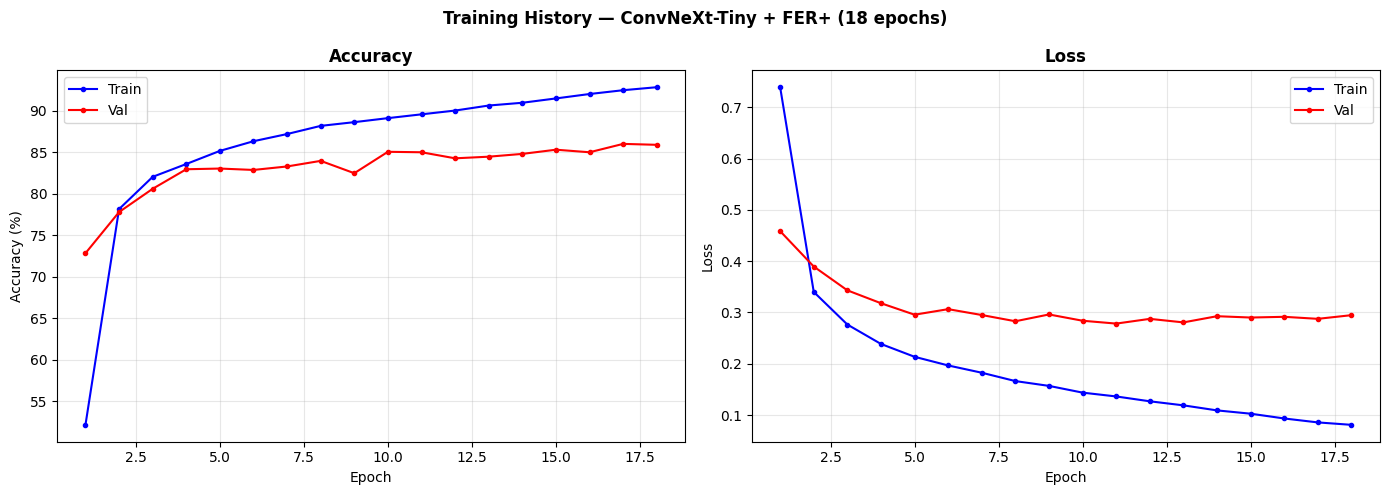

Training berhenti di epoch 18 (early stopping)


In [ ]:
# CELL 11 - Plot Training History
actual_epochs = len(history['train_acc'])  # pakai panjang aktual, bukan EPOCHS
epochs = range(1, actual_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, [a*100 for a in history['train_acc']], 'b-o', ms=3, label='Train')
axes[0].plot(epochs, [a*100 for a in history['val_acc']],   'r-o', ms=3, label='Val')
axes[0].set_title('Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['train_loss'], 'b-o', ms=3, label='Train')
axes[1].plot(epochs, history['val_loss'],   'r-o', ms=3, label='Val')
axes[1].set_title('Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(f'Training History — ConvNeXt-Tiny + FER+ ({actual_epochs} epochs)', fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Training berhenti di epoch {actual_epochs} (early stopping)")

## 5. Evaluation

Model dievaluasi menggunakan test set untuk melihat akurasi, classification report, dan confusion matrix.

Test Accuracy : 84.82%
Test Loss     : 0.2821

=== Classification Report ===
              precision    recall  f1-score   support

     neutral       0.87      0.83      0.85      1302
   happiness       0.94      0.94      0.94       938
    surprise       0.87      0.89      0.88       450
     sadness       0.67      0.77      0.71       442
       anger       0.86      0.78      0.81       313
     disgust       0.56      0.58      0.57        26
        fear       0.62      0.70      0.66        83
    contempt       0.55      0.52      0.53        23

    accuracy                           0.85      3577
   macro avg       0.74      0.75      0.74      3577
weighted avg       0.85      0.85      0.85      3577



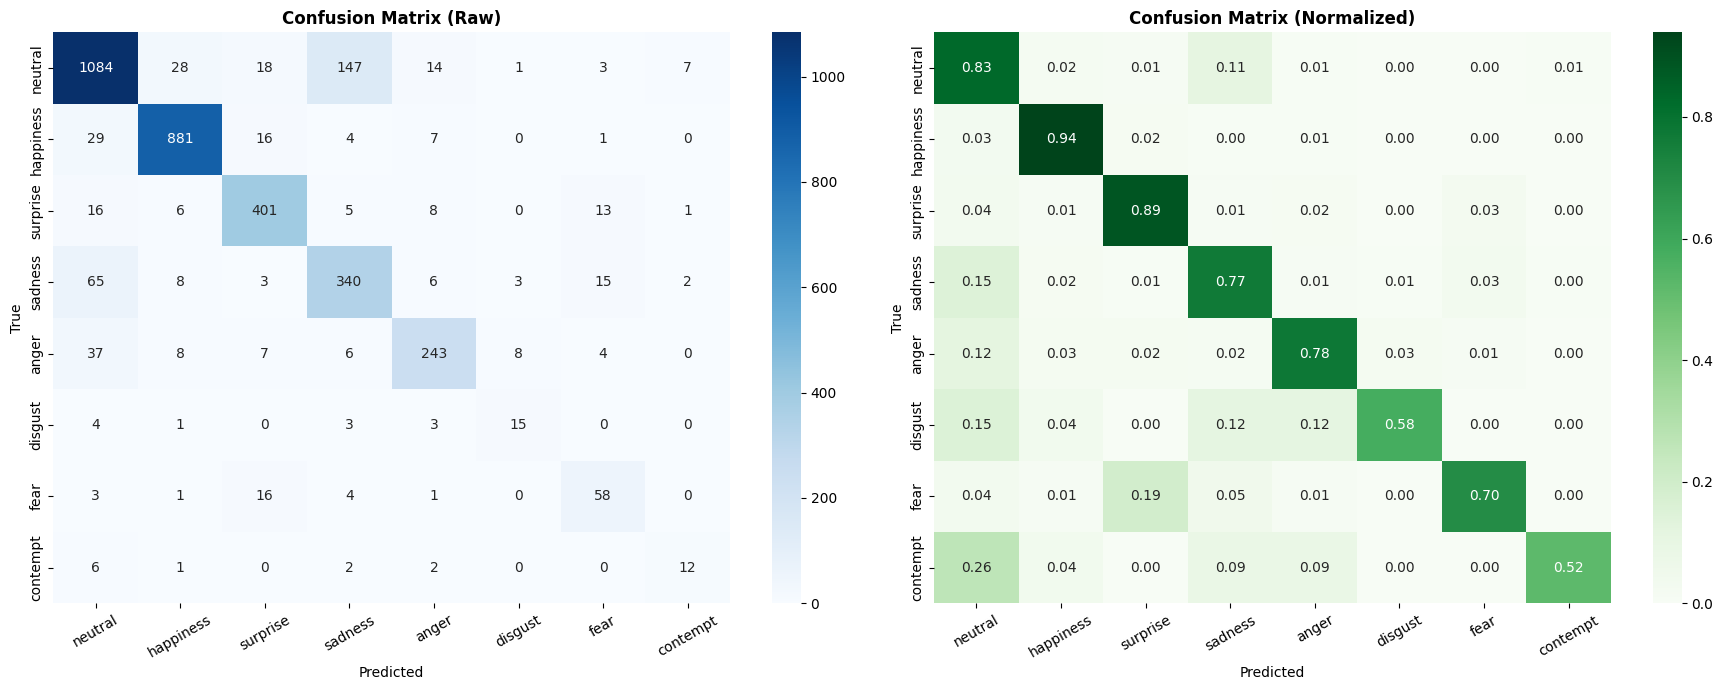

In [ ]:
model.load_state_dict(torch.load('best_convnext_ferplus.pth'))
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

# Classification report
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for imgs, soft_targets, labels in test_loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(labels.numpy())

print("\n=== Classification Report ===")
print(classification_report(all_true, all_preds, target_names=CLASS_NAMES))

# Confusion Matrix
cm = confusion_matrix(all_true, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, data, fmt, title, cmap in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Confusion Matrix (Raw)', 'Confusion Matrix (Normalized)'],
    ['Blues', 'Greens']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


=== DETAILED PER-CLASS ANALYSIS ===

  Emotion  Precision   Recall  F1-Score  Support
 contempt   0.545455 0.521739  0.533333       23
  disgust   0.555556 0.576923  0.566038       26
     fear   0.617021 0.698795  0.655367       83
  sadness   0.665362 0.769231  0.713536      442
    anger   0.855634 0.776358  0.814070      313
  neutral   0.871383 0.832565  0.851532     1302
 surprise   0.869848 0.891111  0.880351      450
happiness   0.943255 0.939232  0.941239      938

=== KESIMPULAN PER KELAS ===
✅ Kelas Terbaik: happiness (F1=0.941)
❌ Kelas Tersulit: contempt (F1=0.533)
📊 Variasi F1 antar kelas: 0.141 (std dev)

=== TOP MISCLASSIFICATIONS ===
     True Predicted  Count
  neutral   sadness    147
  sadness   neutral     65
    anger   neutral     37
happiness   neutral     29
  neutral happiness     28
  neutral  surprise     18
 surprise   neutral     16
happiness  surprise     16
     fear  surprise     16
  sadness      fear     15


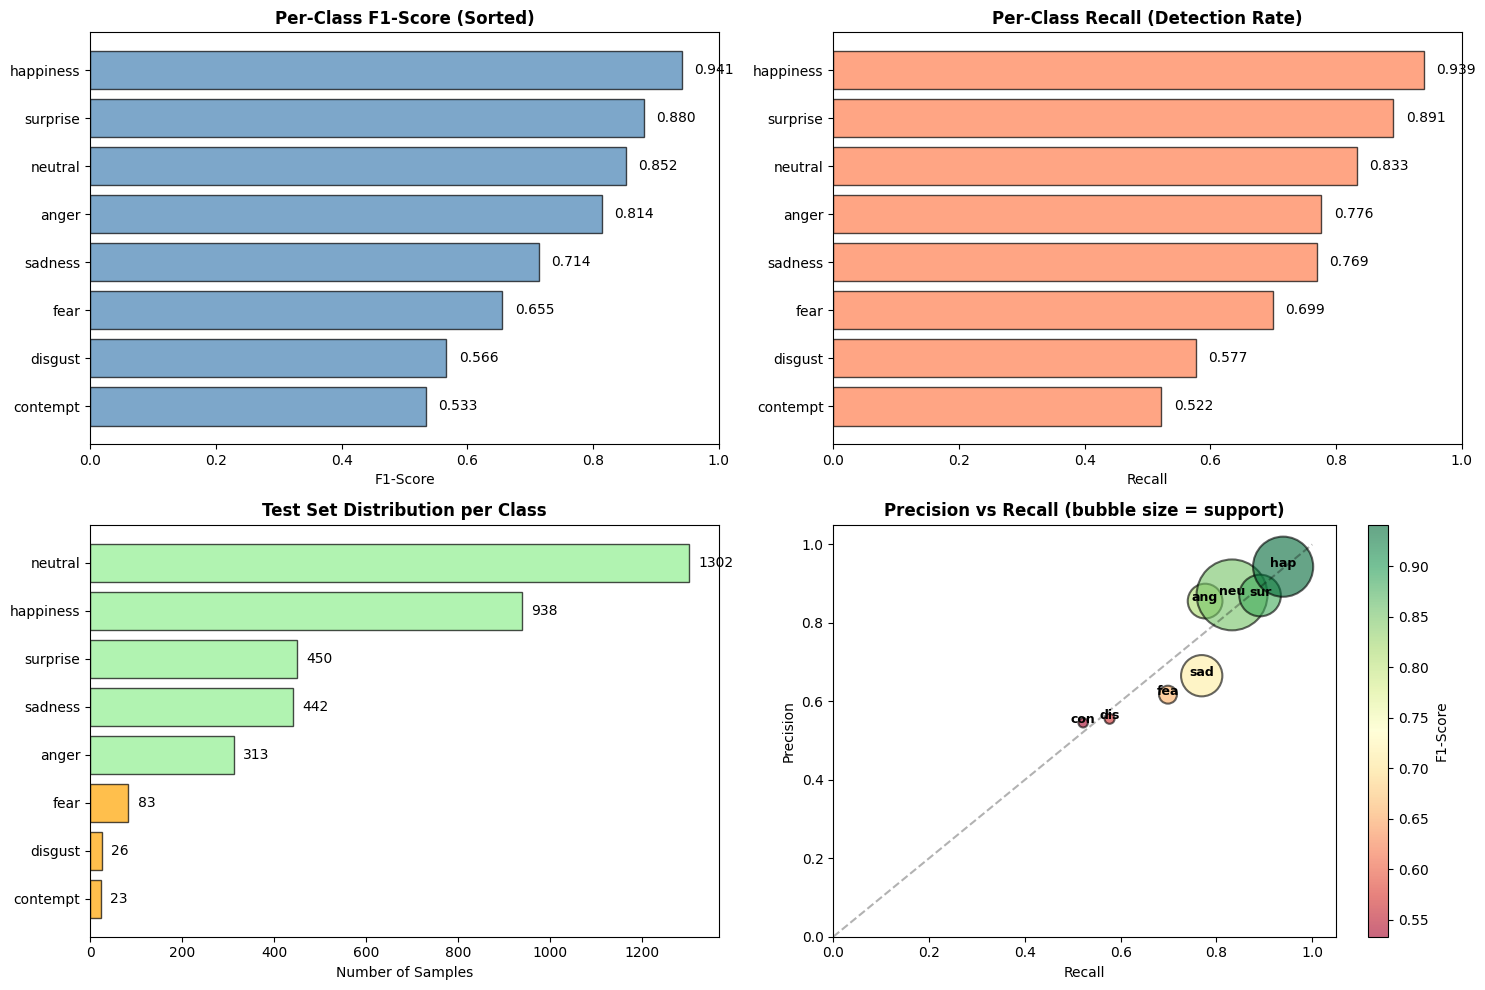


=== INTERPRETASI ===
Model memiliki performa terbaik pada: happiness
Model memiliki performa tersulit pada: contempt

Ratio F1 best/worst: 1.76x


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(
    all_true, all_preds, labels=range(NUM_CLASSES)
)

print("\n=== DETAILED PER-CLASS ANALYSIS ===\n")

# Buat DataFrame untuk visualisasi lebih baik
per_class_df = pd.DataFrame({
    'Emotion': CLASS_NAMES,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
}).sort_values('F1-Score')

print(per_class_df.to_string(index=False))

# Statistik per kelas
print("\n=== KESIMPULAN PER KELAS ===")
print(f"✅ Kelas Terbaik: {CLASS_NAMES[f1.argmax()]} (F1={f1.max():.3f})")
print(f"❌ Kelas Tersulit: {CLASS_NAMES[f1.argmin()]} (F1={f1.min():.3f})")
print(f"📊 Variasi F1 antar kelas: {f1.std():.3f} (std dev)")

# Analisis confusion untuk top misclassifications
print("\n=== TOP MISCLASSIFICATIONS ===")
misclassifications = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j:
            misclassifications.append({
                'True': CLASS_NAMES[i],
                'Predicted': CLASS_NAMES[j],
                'Count': cm[i, j]
            })

misclass_df = pd.DataFrame(misclassifications).sort_values('Count', ascending=False).head(10)
print(misclass_df[misclass_df['Count'] > 0].to_string(index=False))

# Visualisasi per-class performance
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Per-class F1-Score (sorted)
per_class_sorted = per_class_df.sort_values('F1-Score')
axes[0, 0].barh(per_class_sorted['Emotion'], per_class_sorted['F1-Score'],
                 color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('F1-Score')
axes[0, 0].set_title('Per-Class F1-Score (Sorted)', fontweight='bold')
axes[0, 0].set_xlim([0, 1])
for i, v in enumerate(per_class_sorted['F1-Score']):
    axes[0, 0].text(v + 0.02, i, f'{v:.3f}', va='center')

# 2. Per-class Recall (untuk lihat detection rate)
per_class_sorted2 = per_class_df.sort_values('Recall')
axes[0, 1].barh(per_class_sorted2['Emotion'], per_class_sorted2['Recall'],
                 color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_title('Per-Class Recall (Detection Rate)', fontweight='bold')
axes[0, 1].set_xlim([0, 1])
for i, v in enumerate(per_class_sorted2['Recall']):
    axes[0, 1].text(v + 0.02, i, f'{v:.3f}', va='center')

# 3. Per-class Support (sample count)
per_class_support = per_class_df.sort_values('Support')
colors_support = ['orange' if s < per_class_df['Support'].quantile(0.33) else 'lightgreen'
                  for s in per_class_support['Support']]
axes[1, 0].barh(per_class_support['Emotion'], per_class_support['Support'],
                 color=colors_support, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Number of Samples')
axes[1, 0].set_title('Test Set Distribution per Class', fontweight='bold')
for i, v in enumerate(per_class_support['Support']):
    axes[1, 0].text(v + 20, i, str(int(v)), va='center')

# 4. Precision vs Recall scatter (untuk lihat trade-off)
scatter = axes[1, 1].scatter(per_class_df['Recall'], per_class_df['Precision'],
                             s=per_class_df['Support']*2, alpha=0.6,
                             c=per_class_df['F1-Score'], cmap='RdYlGn',
                             edgecolors='black', linewidth=1.5)
for idx, row in per_class_df.iterrows():
    axes[1, 1].annotate(row['Emotion'][:3],
                       (row['Recall'], row['Precision']),
                       fontsize=9, fontweight='bold', ha='center')
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Precision vs Recall (bubble size = support)', fontweight='bold')
axes[1, 1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1, 1].set_xlim([0, 1.05])
axes[1, 1].set_ylim([0, 1.05])
cbar = plt.colorbar(scatter, ax=axes[1, 1])
cbar.set_label('F1-Score')

plt.tight_layout()
plt.savefig('per_class_detailed_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== INTERPRETASI ===")
print(f"Model memiliki performa terbaik pada: {per_class_df.iloc[-1]['Emotion']}")
print(f"Model memiliki performa tersulit pada: {per_class_df.iloc[0]['Emotion']}")
print(f"\nRatio F1 best/worst: {per_class_df.iloc[-1]['F1-Score'] / per_class_df.iloc[0]['F1-Score']:.2f}x")


## 6. Deployment

Tahap akhir berisi penyimpanan model ke beberapa format agar hasil penelitian mudah digunakan kembali pada lingkungan lain.

In [ ]:
!pip install -q onnx onnxscript

# 1. State dict
torch.save(model.state_dict(), 'convnext_ferplus_statedict.pth')
print("Saved: convnext_ferplus_statedict.pth")

# 2. Full model
torch.save(model, 'convnext_ferplus_fullmodel.pth')
print("Saved: convnext_ferplus_fullmodel.pth")

# 3. TorchScript
scripted = torch.jit.script(model.cpu())
scripted.save('convnext_ferplus_scripted.pt')
model = model.to(DEVICE)
print("Saved: convnext_ferplus_scripted.pt")

# 4. ONNX
dummy_input = torch.randn(1, 3, 224, 224).to(DEVICE)
torch.onnx.export(
    model,
    dummy_input,
    'convnext_ferplus.onnx',
    export_params=True,
    opset_version=11,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)
print("Saved: convnext_ferplus.onnx")

# 5. Checkpoint
torch.save({
    'epoch'               : EPOCHS,
    'model_state_dict'    : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_acc'        : best_val_acc,
    'class_names'         : CLASS_NAMES,
    'history'             : history
}, 'convnext_ferplus_checkpoint.pth')
print("Saved: convnext_ferplus_checkpoint.pth")

# 6. Ekspor ke TensorFlow SavedModel / .keras (via ONNX → TF)
# Install dulu: pip install onnx2tf
# Jalankan di terminal / cell baru:
# !pip install -q onnx2tf
# !onnx2tf -i convnext_ferplus.onnx -o convnext_ferplus_tf
# Hasilnya bisa diload dengan:
# import tensorflow as tf
# model_tf = tf.saved_model.load('convnext_ferplus_tf')

print("\n=== Cara Load Tiap Format ===")
print("""
# Format 1 — state dict (butuh definisi model):
import timm
model = timm.create_model('convnext_tiny', pretrained=False, num_classes=8)
model.load_state_dict(torch.load('convnext_ferplus_statedict.pth'))
model.eval()

# Format 2 — full model (paling simpel):
model = torch.load('convnext_ferplus_fullmodel.pth')
model.eval()

# Format 3 — TorchScript (tanpa timm):
model = torch.jit.load('convnext_ferplus_scripted.pt')
model.eval()

# Format 4 — ONNX (pakai OpenCV / ONNX Runtime):
import onnxruntime as ort
sess = ort.InferenceSession('convnext_ferplus.onnx')
output = sess.run(None, {'input': img_numpy})  # img_numpy shape (1,3,224,224)

# Format 5 — resume training dari checkpoint:
ckpt = torch.load('convnext_ferplus_checkpoint.pth')
model.load_state_dict(ckpt['model_state_dict'])
optimizer.load_state_dict(ckpt['optimizer_state_dict'])
class_names = ckpt['class_names']
""")

print("\nSemua model berhasil disimpan!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 129.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 18.2 MB/s eta 0:00:00
Saved: convnext_ferplus_statedict.pth
Saved: convnext_ferplus_fullmodel.pth


ValueError: Unknown type annotation: 'Callable[..., Any]' at 